# HW 6 — Convolutional Neural Networks: Fashion MNIST

## Step 1: Imports & Setup

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# reproducibility — set all seeds before any model is built
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU available:", bool(gpus))

TensorFlow version: 2.21.0
GPU available: False


c:\Users\ldcal\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2: Data Loading & Initial Inspection

In [2]:
# load Fashion MNIST directly from keras — 60k train, 10k test, 28x28 grayscale
(X_train_raw, y_train_raw), (X_test, y_test) = fashion_mnist.load_data()

# class names for the 10 Fashion MNIST categories
class_names = [
    'T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot'
]

print("Train shape:", X_train_raw.shape, "| Labels:", y_train_raw.shape)
print("Test shape:", X_test.shape, "| Labels:", y_test.shape)
print("Pixel range: [{}, {}]".format(X_train_raw.min(), X_train_raw.max()))
print("Classes:", class_names)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28) | Labels: (60000,)
Test shape: (10000, 28, 28) | Labels: (10000,)
Pixel range: [0, 255]
Classes: ['T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']


One thing i noticed in this assingment is that we are trying to indetify a lot more variables than usual, meaning that our models are going to be computing more and having to make more difficult decisions. This indicates that more training and tuning may be necessary to get a predicatble model. 

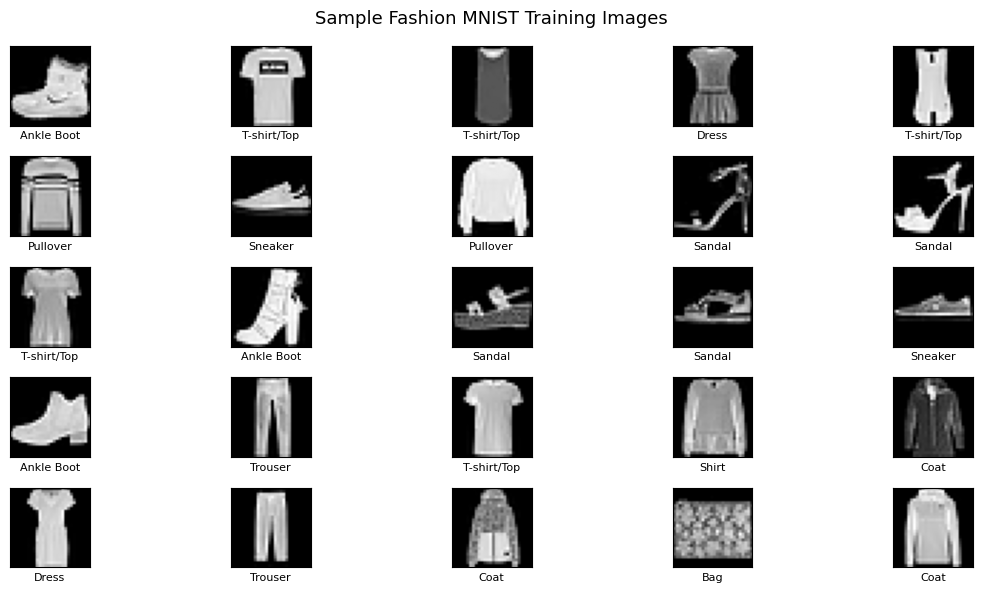

In [3]:
# visualize a sample of training images to understand what we are working with
plt.figure(figsize=(12, 6))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train_raw[i], cmap='gray')
    plt.xlabel(class_names[y_train_raw[i]], fontsize=8)
plt.suptitle('Sample Fashion MNIST Training Images', fontsize=13)
plt.tight_layout()
plt.show()

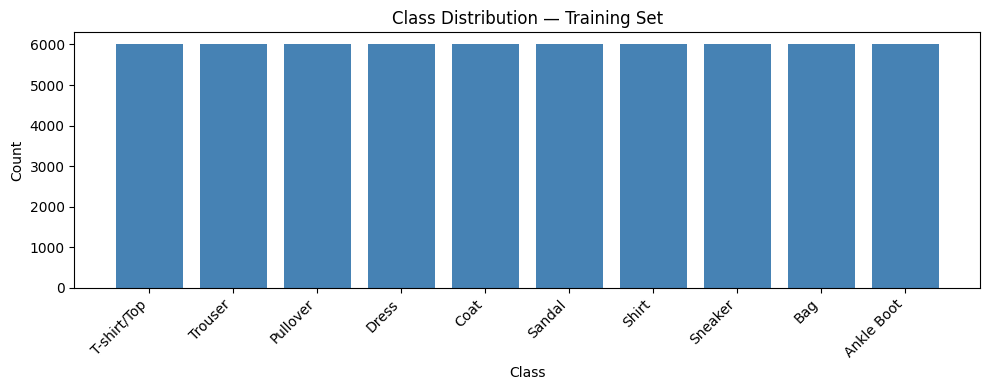

In [4]:
# check class distribution — expect roughly balanced (6,000 per class)
unique, counts = np.unique(y_train_raw, return_counts=True)
plt.figure(figsize=(10, 4))
plt.bar([class_names[i] for i in unique], counts, color='steelblue')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution — Training Set')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This dataset is very indeal for the kind of work we are doing, as their are equal number of items between each class, this shoudl help with the predictatbility of our model as all of the classes have enough examples to mkae good conclusions. 

## Step 3: Preprocessing

In [5]:
# normalize pixel values from 0–255 to 0–1 so gradients stay well-behaved
X_train_norm = X_train_raw / 255.0
X_test_norm = X_test / 255.0

# add channel dimension for CNN: (N, 28, 28) → (N, 28, 28, 1)
# CNNs expect (height, width, channels); grayscale has 1 channel
X_train_cnn = X_train_norm[..., np.newaxis]
X_test_cnn = X_test_norm[..., np.newaxis]

# hold out 10% of training data as a validation set (stratified via numpy)
# using a manual split so the test set is never touched until final evaluation
np.random.seed(42)
val_size = 6000  # 10% of 60k
indices = np.random.permutation(len(X_train_cnn))
val_idx, train_idx = indices[:val_size], indices[val_size:]

X_val, y_val = X_train_cnn[val_idx], y_train_raw[val_idx]
X_train, y_train = X_train_cnn[train_idx], y_train_raw[train_idx]

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test_cnn.shape}")

Train: (54000, 28, 28, 1) | Val: (6000, 28, 28, 1) | Test: (10000, 28, 28, 1)


## Step 4: Baseline CNN

Starting point: two conv blocks (32 → 64 filters) with MaxPooling, followed by a single Dense(64) layer. No regularization, no augmentation. This gives us a performance floor to beat in subsequent experiments.

In [6]:
# set seed immediately before model construction — weights init at keras.Model() time
tf.random.set_seed(42)

cnn_baseline = models.Sequential([
    layers.Input(shape=(28, 28, 1)),                          # 28x28 grayscale

    layers.Conv2D(32, (3, 3), activation='relu',
                  padding='same'),                            # detect edges and simple textures
    layers.MaxPooling2D((2, 2)),                              # halve spatial size → 14x14

    layers.Conv2D(64, (3, 3), activation='relu',
                  padding='same'),                            # detect more complex patterns
    layers.MaxPooling2D((2, 2)),                              # halve again → 7x7

    layers.Flatten(),                                         # 7x7x64 = 3136 features
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')                    # 10-class output
], name='cnn_baseline')

cnn_baseline.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',                   # integer labels, not one-hot
    metrics=['accuracy']
)

cnn_baseline.summary()

Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history_baseline = cnn_baseline.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=128,
    verbose=1
)

baseline_loss, baseline_acc = cnn_baseline.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Baseline Test Accuracy: {baseline_acc:.4f}")

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8174 - loss: 0.5124 - val_accuracy: 0.8737 - val_loss: 0.3540
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8849 - loss: 0.3236 - val_accuracy: 0.8918 - val_loss: 0.3091
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9005 - loss: 0.2787 - val_accuracy: 0.8913 - val_loss: 0.3002
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9103 - loss: 0.2500 - val_accuracy: 0.8905 - val_loss: 0.2945
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9176 - loss: 0.2274 - val_accuracy: 0.8957 - val_loss: 0.2887
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9239 - loss: 0.2080 - val_accuracy: 0.8967 - val_loss: 0.2866
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9298 - loss: 0.1909 - val_accuracy: 0.8988 - val_loss: 0.2829
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9354 - loss: 0.1762 - val_accu

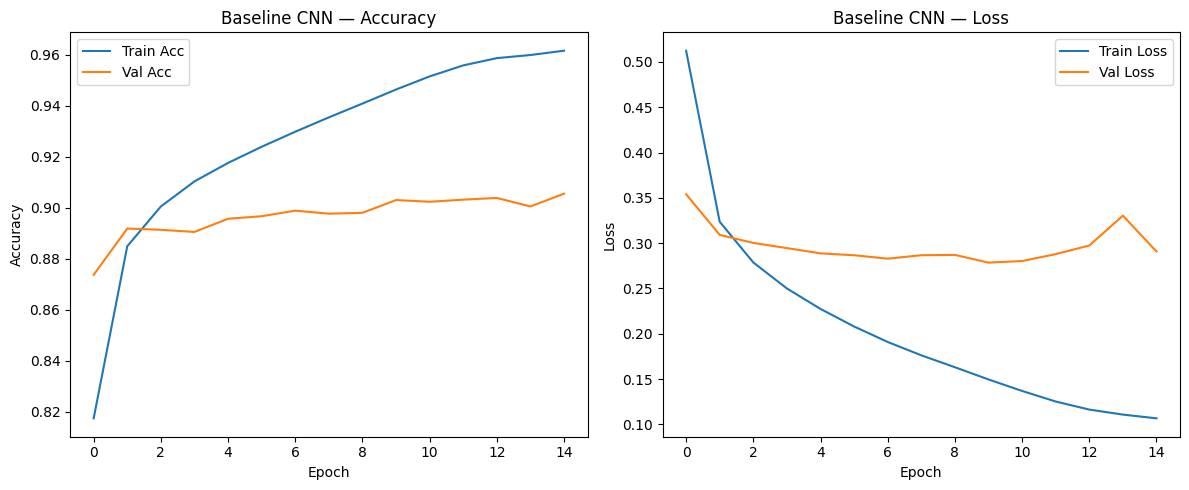

In [8]:
def plot_history(history, title):
    """Plot training and validation accuracy + loss curves."""
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{title} — Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} — Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_baseline, 'Baseline CNN')

Looking at the first model we can see high differences in the traing vs validation set, and with acccuracy we see a positive trend that looks like it can keep going, indicating the we probably stopped too early. Same thing with the loss of this model, figuring out how to add more varaibles and tune for our model will help bridge this gap. 

## Step 5: Experiments

Each experiment changes **one factor** relative to the previous best, so we can attribute changes in performance to a specific design decision. The baseline result is our anchor.

| # | Change from baseline | Purpose |
|---|---|---|
| Baseline | 2 conv blocks [32, 64], Dense(64), no reg | Reference point |
| Exp 1 | Add a 3rd conv block (128 filters) | Isolate depth effect |
| Exp 2 | Exp 1 + Dropout(0.3) after Dense | Isolate dropout effect |
| Exp 3 | Exp 2 + data augmentation (flip + rotation) | Isolate augmentation effect |
| Exp 4 | Exp 3 + BatchNormalization after each conv | Isolate batch norm effect |

### Experiment 1 — Deeper Architecture (one factor: add 3rd conv block)

In [9]:
tf.random.set_seed(42)

cnn_exp1 = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # added third conv block — more capacity to learn fine-grained patterns
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),                               # 3x3 after this pool

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='cnn_exp1_deeper')

cnn_exp1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_exp1 = cnn_exp1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=128,
    verbose=1
)

exp1_loss, exp1_acc = cnn_exp1.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Exp 1 (Deeper) Test Accuracy: {exp1_acc:.4f}")

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.7970 - loss: 0.5656 - val_accuracy: 0.8615 - val_loss: 0.3865
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8762 - loss: 0.3420 - val_accuracy: 0.8852 - val_loss: 0.3279
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8942 - loss: 0.2921 - val_accuracy: 0.8917 - val_loss: 0.3063
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9066 - loss: 0.2588 - val_accuracy: 0.8978 - val_loss: 0.2781
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9151 - loss: 0.2333 - val_accuracy: 0.9012 - val_loss: 0.2683
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9227 - loss: 0.2124 - val_accuracy: 0.9048 - val_loss: 0.2650
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9286 - loss: 0.1939 - val_accuracy: 0.9057 - val_loss: 0.2637
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9364 - loss: 0.1765 - val_ac

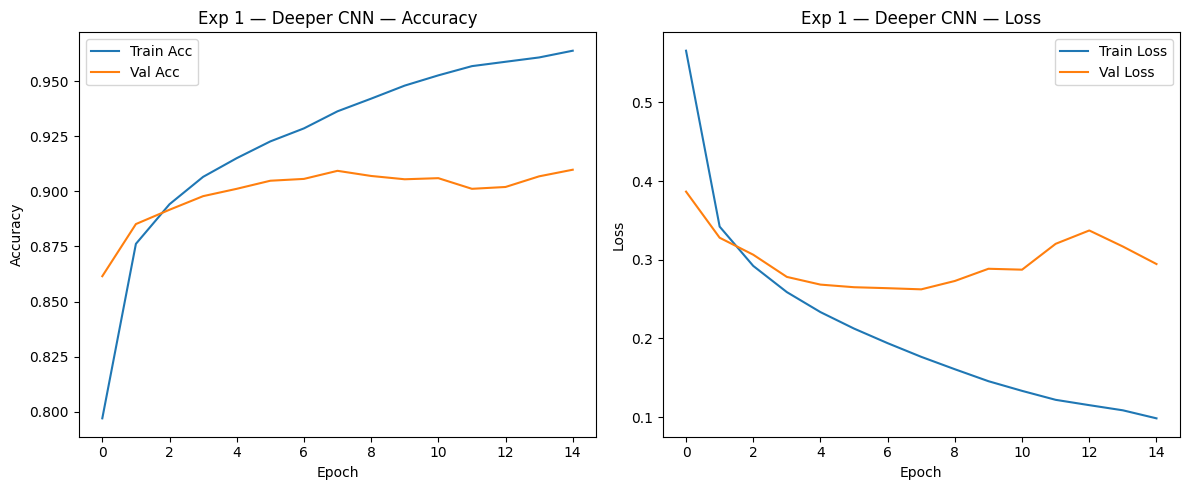

In [10]:
plot_history(history_exp1, 'Exp 1 — Deeper CNN')

In this first experiment we can see that the loss is impoorving and our accuracy is getting better, however their is still a signifcant gap indicating overfitting. 

### Experiment 2 — Dropout Regularization (one factor: add Dropout(0.3))

In [11]:
tf.random.set_seed(42)

cnn_exp2 = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),                                      # randomly zero 30% of neurons each step to reduce overfitting
    layers.Dense(10, activation='softmax')
], name='cnn_exp2_dropout')

cnn_exp2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_exp2 = cnn_exp2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=128,
    verbose=1
)

exp2_loss, exp2_acc = cnn_exp2.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Exp 2 (Dropout) Test Accuracy: {exp2_acc:.4f}")

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.7614 - loss: 0.6626 - val_accuracy: 0.8488 - val_loss: 0.4033
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8604 - loss: 0.3941 - val_accuracy: 0.8892 - val_loss: 0.3202
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8824 - loss: 0.3318 - val_accuracy: 0.8877 - val_loss: 0.3122
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8930 - loss: 0.2985 - val_accuracy: 0.8952 - val_loss: 0.2907
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9019 - loss: 0.2739 - val_accuracy: 0.9047 - val_loss: 0.2638
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9073 - loss: 0.2565 - val_accuracy: 0.9115 - val_loss: 0.2485
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9144 - loss: 0.2357 - val_accuracy: 0.9138 - val_loss: 0.2457
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9199 - loss: 0.2213 - val_ac

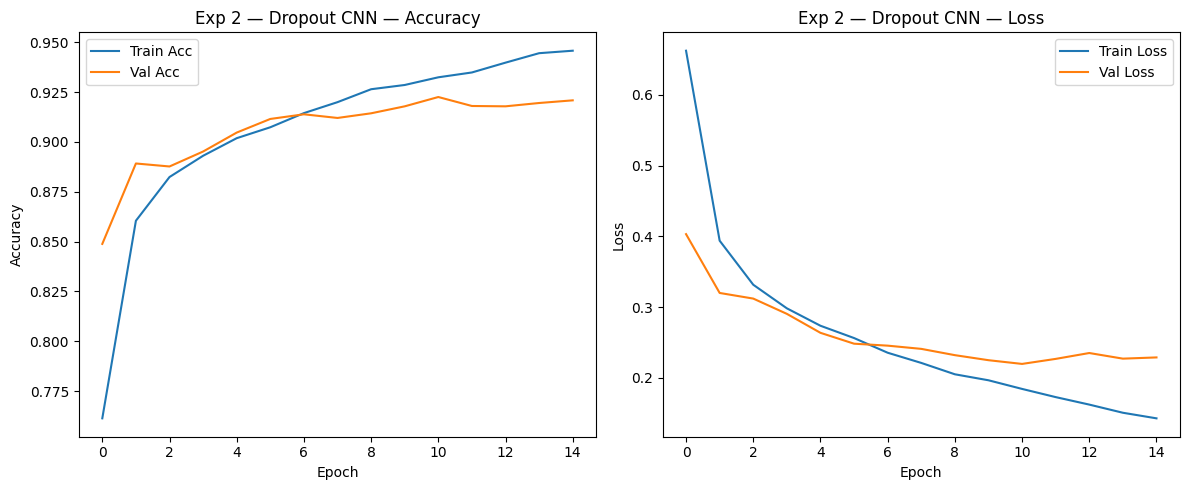

In [12]:
plot_history(history_exp2, 'Exp 2 — Dropout CNN')

Adding a droppout metric to our basde model helped with the overfitting signifcantly, although our metrics are not improving seeing this is a really important improvement and is something that i look for in each step of my modeling. 

### Experiment 3 — Data Augmentation (one factor: add RandomFlip + RandomRotation)

In [13]:
tf.random.set_seed(42)

# augmentation is applied only during training — increases effective dataset size
data_augmentation = models.Sequential([
    layers.RandomFlip('horizontal'),          # many clothing items are symmetric left/right
    layers.RandomRotation(0.05),              # small rotations reflect real-world variation
], name='augmentation')

cnn_exp3 = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
], name='cnn_exp3_augmentation')

cnn_exp3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_exp3 = cnn_exp3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,                                                # augmentation slows convergence — train a bit longer
    batch_size=128,
    verbose=1
)

exp3_loss, exp3_acc = cnn_exp3.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Exp 3 (Augmentation) Test Accuracy: {exp3_acc:.4f}")

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.7074 - loss: 0.8074 - val_accuracy: 0.8217 - val_loss: 0.4705
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.8165 - loss: 0.5085 - val_accuracy: 0.8485 - val_loss: 0.4052
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8395 - loss: 0.4417 - val_accuracy: 0.8677 - val_loss: 0.3710
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8531 - loss: 0.4017 - val_accuracy: 0.8767 - val_loss: 0.3434
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8642 - loss: 0.3772 - val_accuracy: 0.8850 - val_loss: 0.3167
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8705 - loss: 0.3542 - val_accuracy: 0.8912 - val_loss: 0.3079
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8774 - loss: 0.3392 - val_accuracy: 0.8958 - val_loss: 0.2956
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8809 - loss: 0.3293 - 

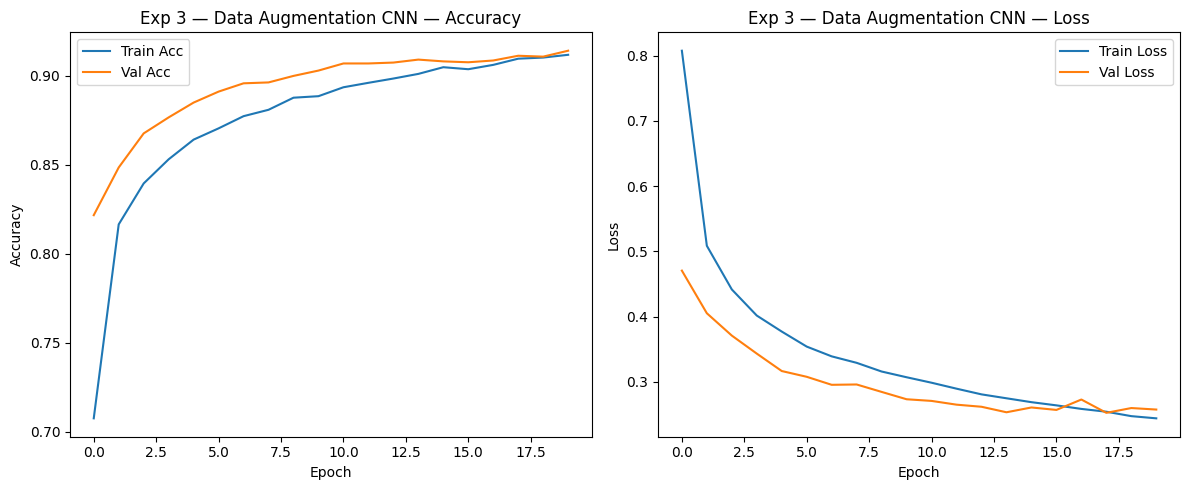

In [14]:
plot_history(history_exp3, 'Exp 3 — Data Augmentation CNN')

This experiment also helped to improve our model, dealing with overfitting again by altering some of the photos we were training on, making our model better when looking at photos that may be more obscure. 

### Experiment 4 — Batch Normalization (one factor: add BatchNorm after each conv)

In [15]:
tf.random.set_seed(42)

data_augmentation = models.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
], name='augmentation')

cnn_exp4 = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),                              # normalizes activations; stabilizes and speeds training
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
], name='cnn_exp4_batchnorm')

cnn_exp4.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_exp4 = cnn_exp4.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    verbose=1
)

exp4_loss, exp4_acc = cnn_exp4.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Exp 4 (BatchNorm) Test Accuracy: {exp4_acc:.4f}")

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.7507 - loss: 0.7096 - val_accuracy: 0.7167 - val_loss: 0.6922
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.8321 - loss: 0.4682 - val_accuracy: 0.8680 - val_loss: 0.3702
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.8513 - loss: 0.4152 - val_accuracy: 0.8683 - val_loss: 0.3448
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.8611 - loss: 0.3850 - val_accuracy: 0.8862 - val_loss: 0.3109
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.8695 - loss: 0.3643 - val_accuracy: 0.8872 - val_loss: 0.3103
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.8773 - loss: 0.3427 - val_accuracy: 0.8890 - val_loss: 0.2946
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.8833 - loss: 0.3256 - val_accuracy: 0.8948 - val_loss: 0.2906
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.8859 - loss: 0.3159 - 

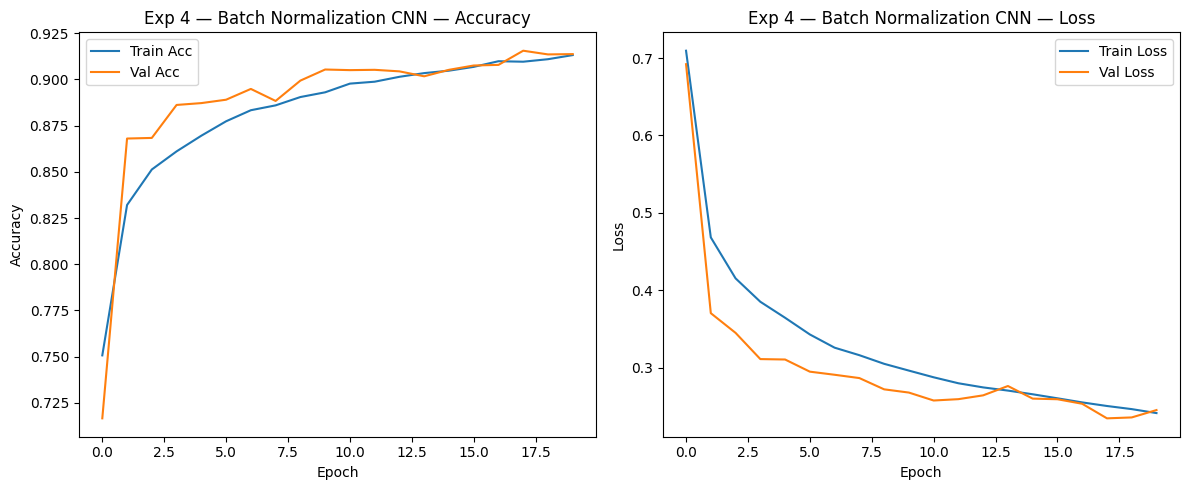

In [16]:
plot_history(history_exp4, 'Exp 4 — Batch Normalization CNN')

Adding batch nomralization omly benfiited our model, this metric is something we should be implemnting in all CNN models as i dont see a drawback in not using it, speeds up training time which is very helpful. 

### Experiment Summary

In [17]:
# consolidate results across all experiments for easy comparison
results = pd.DataFrame({
    'Model': ['Baseline', 'Exp1 Deeper', 'Exp2 Dropout', 'Exp3 Augmentation', 'Exp4 BatchNorm'],
    'Test Accuracy': [baseline_acc, exp1_acc, exp2_acc, exp3_acc, exp4_acc],
    'Key Change': [
        '2 conv blocks, no reg',
        '+ 3rd conv block (128 filters)',
        '+ Dropout(0.3)',
        '+ RandomFlip + RandomRotation',
        '+ BatchNorm after each conv'
    ]
})

results['Test Accuracy'] = results['Test Accuracy'].round(4)
print(results.to_string(index=False))

            Model  Test Accuracy                     Key Change
         Baseline         0.9036          2 conv blocks, no reg
      Exp1 Deeper         0.9070 + 3rd conv block (128 filters)
     Exp2 Dropout         0.9171                 + Dropout(0.3)
Exp3 Augmentation         0.9088  + RandomFlip + RandomRotation
   Exp4 BatchNorm         0.9105    + BatchNorm after each conv


## Step 6: Systematic Tuning with Optuna

Using Optuna's Bayesian optimization to search over the most impactful hyperparameters: number of conv blocks, filter sizes, dropout rate, learning rate, and batch size. We tune against validation accuracy to avoid test-set leakage.

In [18]:
def build_cnn(trial, input_shape=(28, 28, 1), n_classes=10):
    """Build a CNN whose architecture is controlled by Optuna trial parameters."""
    # set seed before each model build for consistent weight initialization
    tf.random.set_seed(42)

    n_blocks = trial.suggest_int('n_blocks', 2, 4)
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    use_batchnorm = trial.suggest_categorical('use_batchnorm', [True, False])
    use_augmentation = trial.suggest_categorical('use_augmentation', [True, False])

    model_layers = [layers.Input(shape=input_shape)]

    if use_augmentation:
        aug = models.Sequential([
            layers.RandomFlip('horizontal'),
            layers.RandomRotation(0.05),
        ])
        model_layers.append(aug)

    base_filters = 32
    for i in range(n_blocks):
        filters = trial.suggest_int(f'filters_b{i}', base_filters * (2**i), base_filters * (2**(i+1)), step=32)
        model_layers.append(layers.Conv2D(filters, (3, 3), padding='same'))
        if use_batchnorm:
            model_layers.append(layers.BatchNormalization())
        model_layers.append(layers.Activation('relu'))
        model_layers.append(layers.MaxPooling2D((2, 2)))

    model_layers.append(layers.Flatten())
    dense_units = trial.suggest_int('dense_units', 64, 256, step=64)
    model_layers.append(layers.Dense(dense_units, activation='relu'))
    if dropout_rate > 0:
        model_layers.append(layers.Dropout(dropout_rate))
    model_layers.append(layers.Dense(n_classes, activation='softmax'))

    model = models.Sequential(model_layers)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def objective(trial):
    model = build_cnn(trial)
    es = keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, mode='max'
    )
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=25,
        batch_size=128,
        callbacks=[es],
        verbose=0
    )
    return max(history.history['val_accuracy'])


study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=25)

print("Best val accuracy:", round(study.best_value, 4))
print("Best params:", study.best_params)

Best val accuracy: 0.9307
Best params: {'n_blocks': 2, 'dropout_rate': 0.34396565275949936, 'lr': 0.0011263402790402325, 'use_batchnorm': False, 'use_augmentation': False, 'filters_b0': 64, 'filters_b1': 96, 'dense_units': 128}


This tuning took far too long and was probably unnessesary for the about of improvement in the model we saw (took 261 mins) to run this code block. Understanding what varaibles we should hold constant and which ones to tune for will help refine the amount of time we are taking on running these experiments. 

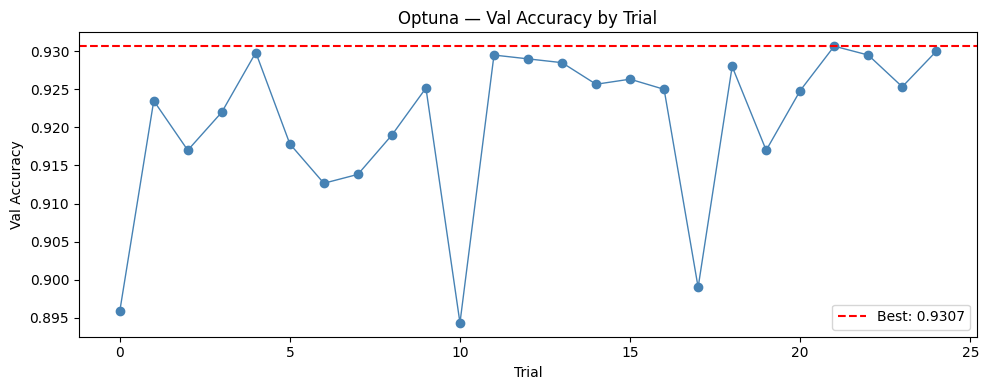

In [19]:
# visualize Optuna trial outcomes to see how the search progressed
trial_vals = [t.value for t in study.trials if t.value is not None]
plt.figure(figsize=(10, 4))
plt.plot(trial_vals, marker='o', color='steelblue', linewidth=1)
plt.axhline(y=max(trial_vals), color='red', linestyle='--', label=f'Best: {max(trial_vals):.4f}')
plt.xlabel('Trial')
plt.ylabel('Val Accuracy')
plt.title('Optuna — Val Accuracy by Trial')
plt.legend()
plt.tight_layout()
plt.show()

## Step 7: Final Model

Retrain on the full training set (train + validation) using the best hyperparameters found by Optuna. This is the only point where the test set is used for evaluation.

In [20]:
# retrieve best params and build the final model
best_params = study.best_params
print("Building final model with:", best_params)

# reconstruct from best trial
best_trial = study.best_trial

tf.random.set_seed(42)
final_model = build_cnn(best_trial)
final_model.summary()

# combine train + val for final training — more data, same held-out test set
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)

es_final = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
rlr_final = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3
)

history_final = final_model.fit(
    X_trainval, y_trainval,
    validation_split=0.1,                                     # small internal val for callbacks only
    epochs=40,
    batch_size=128,
    callbacks=[es_final, rlr_final],
    verbose=1
)

Building final model with: {'n_blocks': 2, 'dropout_rate': 0.34396565275949936, 'lr': 0.0011263402790402325, 'use_batchnorm': False, 'use_augmentation': False, 'filters_b0': 64, 'filters_b1': 96, 'dense_units': 128}


Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_78 (Conv2D)              │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_67 (Activation)      │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_78 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 14, 14, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_68 (Activation)      │ (None, 14, 14, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_79 (MaxPooling2D) │ (None, 7, 7, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_30 (Flatten)            │ (None, 4704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 128)            │       602,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 659,562 (2.52 MB)

 Trainable params: 659,562 (2.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.8189 - loss: 0.5110 - val_accuracy: 0.8822 - val_loss: 0.3332 - learning_rate: 0.0011
Epoch 2/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.8861 - loss: 0.3191 - val_accuracy: 0.8975 - val_loss: 0.2808 - learning_rate: 0.0011
Epoch 3/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.9022 - loss: 0.2715 - val_accuracy: 0.9067 - val_loss: 0.2583 - learning_rate: 0.0011
Epoch 4/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.9128 - loss: 0.2394 - val_accuracy: 0.9107 - val_loss: 0.2524 - learning_rate: 0.0011
Epoch 5/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.9206 - loss: 0.2164 - val_accuracy: 0.9127 - val_loss: 0.2292 - learning_rate: 0.0011
Epoch 6/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.9271 - loss: 0.1965 - val_accuracy: 0.9197 - val_loss: 0.2173 - learning_rate: 0.0011
Epoch 7/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.9319 - l

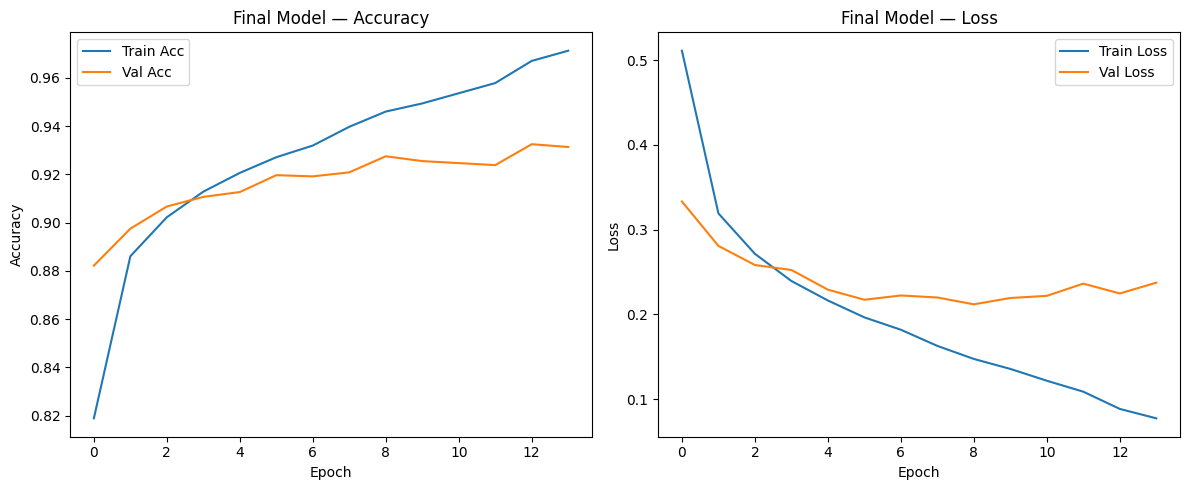

In [21]:
plot_history(history_final, 'Final Model')

Although our final model has great accuracy and loss, we do notice that we did not bridge the gap between train and val. Tuning for less varibles may help with this as we can look at only the values that are important in changing the model. 

## Step 8: Final Test-Set Evaluation

In [22]:
# evaluate on test set — never used during training or tuning
final_test_loss, final_test_acc = final_model.evaluate(X_test_cnn, y_test, verbose=0)
y_pred_proba = final_model.predict(X_test_cnn, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print(f"Final Test Accuracy:  {final_test_acc:.4f}")
print(f"Final Test Loss:      {final_test_loss:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=class_names))

Final Test Accuracy:  0.9192
Final Test Loss:      0.2320

              precision    recall  f1-score   support

 T-shirt/Top       0.84      0.90      0.87      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.85      0.90      0.87      1000
       Dress       0.92      0.93      0.93      1000
        Coat       0.89      0.85      0.87      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.79      0.73      0.76      1000
     Sneaker       0.94      0.99      0.96      1000
         Bag       0.99      0.98      0.99      1000
  Ankle Boot       0.99      0.95      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



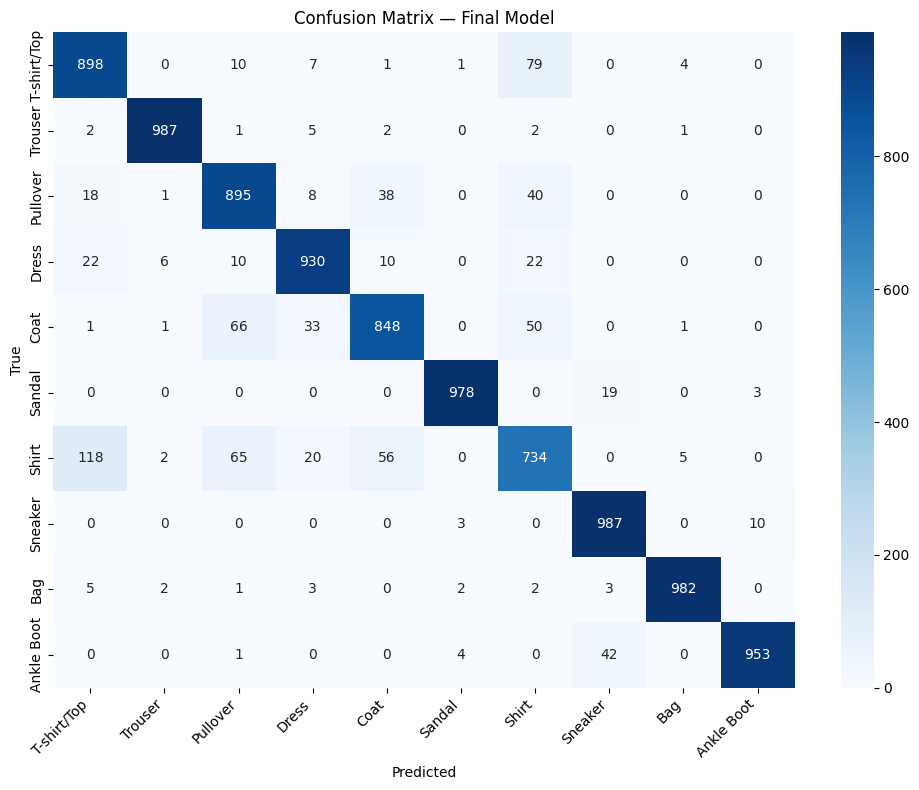

In [23]:
# confusion matrix — shows which classes are most commonly confused
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Final Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

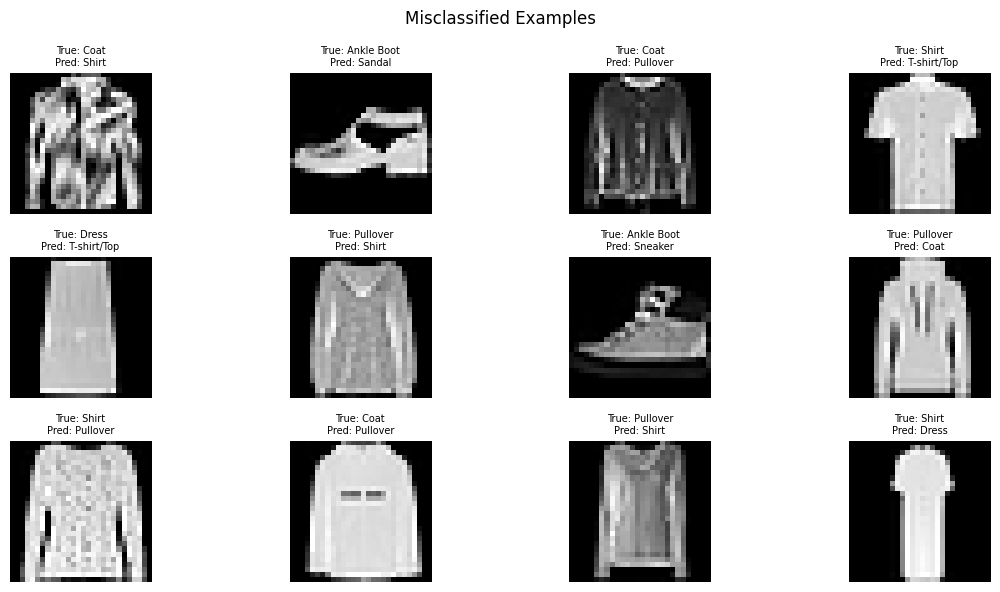

In [24]:
# visualize misclassified examples — useful for understanding where the model fails
misclassified = np.where(y_pred != y_test)[0]

plt.figure(figsize=(12, 6))
for i, idx in enumerate(misclassified[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}", fontsize=7)
    plt.axis('off')
plt.suptitle('Misclassified Examples', fontsize=12)
plt.tight_layout()
plt.show()

A lot of these false classifactions are mostly due to simmilar categories, combining things like t-shir/top and shirt classes together would imporove our model significantly. 

## Step 9: Summary & Conclusions

**Results across all models:**

In [25]:
# final summary table including the Optuna-tuned model
summary = pd.DataFrame({
    'Model': ['Baseline', 'Exp1 Deeper', 'Exp2 Dropout', 'Exp3 Augmentation', 'Exp4 BatchNorm', 'Final (Optuna)'],
    'Test Accuracy': [baseline_acc, exp1_acc, exp2_acc, exp3_acc, exp4_acc, final_test_acc],
    'Key Change': [
        '2 conv blocks, no reg',
        '+ 3rd conv block (128 filters)',
        '+ Dropout(0.3)',
        '+ RandomFlip + RandomRotation',
        '+ BatchNorm after each conv',
        'Optuna search over arch + dropout + lr'
    ]
})

summary['Test Accuracy'] = summary['Test Accuracy'].round(4)
print(summary.to_string(index=False))

            Model  Test Accuracy                             Key Change
         Baseline         0.9036                  2 conv blocks, no reg
      Exp1 Deeper         0.9070         + 3rd conv block (128 filters)
     Exp2 Dropout         0.9171                         + Dropout(0.3)
Exp3 Augmentation         0.9088          + RandomFlip + RandomRotation
   Exp4 BatchNorm         0.9105            + BatchNorm after each conv
   Final (Optuna)         0.9192 Optuna search over arch + dropout + lr


In the future i liked running experiments and seeing how individual factors affected the model, i think part of what i would do for CNN is because we are working with such a good model, being sure to hold several factors consstant can help predictability. Also using the factors that help with overfitting can improve the workflow. in the future especially with large classification datasets, feature engineering classes that are simmilar can help improve predictability without taking away too much from our overall model. 